# Notebook 04 — Dense Autoencoder

**TFG:** Electricity Consumption Anomaly Detection and Mitigation of FDI Attacks in Edge Computing

---

### What changed in v4

| Limitation in v3 | Fix in v4 |
|---|---|
| `mode='medium'` + `vi_res_abs` (14 features) dropped the most discriminative signals | **`mode='full'` (17 features)** with a warm-up buffer |
| Bottleneck of 3 was too tight for 14 features | **Bottleneck of 4** (17:4 = 4.25:1 compression) |
| F1 calibration overlooked low-severity attacks | **F2 calibration**, which prioritises recall |
| Plain ReLU can saturate to zero under negative gradients | **LeakyReLU**, which keeps the gradient alive |
| No GPU configuration | **Metal GPU** with memory growth enabled |

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, time, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, fbeta_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib

tf.random.set_seed(42)

# ── Metal GPU config ──
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Metal GPU: {gpus[0].name} (memory growth ON)')
    BATCH_SIZE = 1024
else:
    print('CPU mode')
    BATCH_SIZE = 512

print(f'TensorFlow {tf.__version__} | numpy {np.__version__}')
print(f'Batch: {BATCH_SIZE}')
print('OK')


Metal GPU: /physical_device:GPU:0 (memory growth ON)
TensorFlow 2.18.1 | numpy 2.0.2
Batch: 1024
OK


## 1. Loading the Real Data

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                        index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)

print('DATA LOADED (real UCI)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_atk = (d['label'] == 1).sum() if 'label' in d.columns else 0
    rng = f'{d.index.min().date()} → {d.index.max().date()}'
    atk = f'  | {n_atk:,} attacks ({n_atk/len(d)*100:.1f}%)' if n_atk else ''
    print(f'  {nm:6s} {len(d):>10,} rows  {rng}{atk}')

DATA LOADED (real UCI)
  Train   1,300,061 rows  2006-12-16 → 2009-06-09
  Val       144,452 rows  2009-06-09 → 2009-09-20  | 21,739 attacks (15.0%)
  Test      604,999 rows  2009-09-20 → 2010-11-26  | 96,717 attacks (16.0%)


## 2. Feature Engineering (`mode='full'`, 17 features)

**Change in v4:** we now use `mode='full'` (17 features), matching the feature set used by the Isolation Forest in NB03. The previous `mode='medium'` + `vi_res_abs` configuration (14 features) discarded the three most discriminative signals: `vi_res_roll15_mean`, `gap_intensity_ratio`, and `sm_gap_ratio`.

In [3]:
def compute_features(df, mode='full'):
    '''
    Compute the derived features. Kept identical to NB02 for consistency.
      base   (8):  7 sensors + VI_residual
      medium (13): + temporal (cyclical) + first difference
      full   (17): + physics-based features
    '''
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs'] = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio'] = (
            df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        )
        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8
        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)
    return f

# ── v4: switch to mode='full' (17 features) ───────────────────────
# v3 used mode='medium' + vi_res_abs = 14 features.
# v4 uses mode='full' = 17 features (same set as the IF in NB03),
# adding vi_res_abs, vi_res_roll15_mean, gap_intensity_ratio, sm_gap_ratio.
WARMUP = 30

X_train_df = compute_features(df_train, mode='full')

# Val: prepend the tail of train so the rolling stats start from valid history
_val_buf = pd.concat([df_train.iloc[-WARMUP:], df_val])
_val_feat = compute_features(_val_buf, mode='full')
X_val_df  = _val_feat.iloc[WARMUP:]

# Test: prepend the tail of val for the same reason
_test_buf = pd.concat([df_val.iloc[-WARMUP:], df_test])
_test_feat = compute_features(_test_buf, mode='full')
X_test_df  = _test_feat.iloc[WARMUP:]

feat_names = list(X_train_df.columns)

# ── RobustScaler: centres on the median and scales by the IQR, so heavy-tailed
#    sensor outliers do not distort the normalisation ──
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_df.values)
X_val   = scaler.transform(X_val_df.values)
X_test  = scaler.transform(X_test_df.values)

X_train = np.nan_to_num(X_train, nan=0.0)
X_val   = np.nan_to_num(X_val, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

y_val  = df_val['label'].values
y_test = df_test['label'].values
n_features = X_train.shape[1]

print(f'Features ({n_features}): {feat_names}')
print(f'Scaler: RobustScaler (median/IQR)')
print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}')

Features (17): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio']
Scaler: RobustScaler (median/IQR)
X_train: (1300061, 17)  |  X_val: (144452, 17)  |  X_test: (604999, 17)


## 3. Architecture

**No BatchNorm (v3):** batch normalisation rescales activations at inference time, which narrows the gap between normal and anomalous inputs, the very gap we rely on for detection.

**Bottleneck = 4 (v4):** a 17:4 = 4.25:1 compression ratio. With 17 input features the bottleneck has to be slightly wider than it was for 14 so that no useful information is squeezed out.

**LeakyReLU (v4):** avoids the "dead neuron" problem, where a plain ReLU zeroes out negative gradients. This matters for anomaly detection because we want the activations to register deviations in either direction.

Architecture: 17 → 64 → 32 → **4** → 32 → 64 → 17

In [4]:
def build_autoencoder(n_features, bottleneck=4):
    inp = Input(shape=(n_features,), name='input')

    # Encoder (LeakyReLU, no BatchNorm)
    x = Dense(64, name='enc1')(inp)
    x = LeakyReLU(negative_slope=0.1)(x)
    x = Dense(32, name='enc2')(x)
    x = LeakyReLU(negative_slope=0.1)(x)
    encoded = Dense(bottleneck, activation='relu', name='bottleneck')(x)

    # Decoder (mirror of the encoder)
    x = Dense(32, name='dec1')(encoded)
    x = LeakyReLU(negative_slope=0.1)(x)
    x = Dense(64, name='dec2')(x)
    x = LeakyReLU(negative_slope=0.1)(x)
    decoded = Dense(n_features, activation='linear', name='output')(x)

    model = Model(inp, decoded, name='dense_autoencoder_v4')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4), loss='mse')
    return model

ae = build_autoencoder(n_features, bottleneck=4)
ae.summary()
print(f'\nTrainable parameters: {ae.count_params():,}')
print(f'Compression ratio: {n_features}:4 = {n_features/4:.1f}:1')

2026-06-07 14:52:58.949107: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-07 14:52:58.950052: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-07 14:52:58.950075: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780836778.959941 4005786 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780836778.960680 4005786 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "dense_autoencoder_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1 (Dense)                    │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec1 (Dense)                    │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec2 (Dense)                    │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,741 (26.33 KB)

 Trainable params: 6,741 (26.33 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters: 6,741
Compression ratio: 17:4 = 4.2:1


## 4. Training

In [5]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history = ae.fit(
    X_train, X_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
t_train = time.time() - t0
print(f'\nTraining: {t_train:.1f} s | {len(history.history["loss"])} epochs')

Epoch 1/50


2026-06-07 14:53:00.912756: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1143/1143 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 2.6461 - val_loss: 0.2497 - learning_rate: 5.0000e-04
Epoch 2/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2441 - val_loss: 0.2074 - learning_rate: 5.0000e-04
Epoch 3/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.2110 - val_loss: 0.2024 - learning_rate: 5.0000e-04
Epoch 4/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2031 - val_loss: 0.1875 - learning_rate: 5.0000e-04
Epoch 5/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.1849 - val_loss: 0.1732 - learning_rate: 5.0000e-04
Epoch 6/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.1728 - val_loss: 0.1646 - learning_rate: 5.0000e-04
Epoch 7/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.2032 - val_loss: 0.1757 - learning_rate: 5.0000e-04
Epoch 8/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.1704 - val_loss: 0.1567 - learning_rate: 5.0000e-04
Epoch 9/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.15

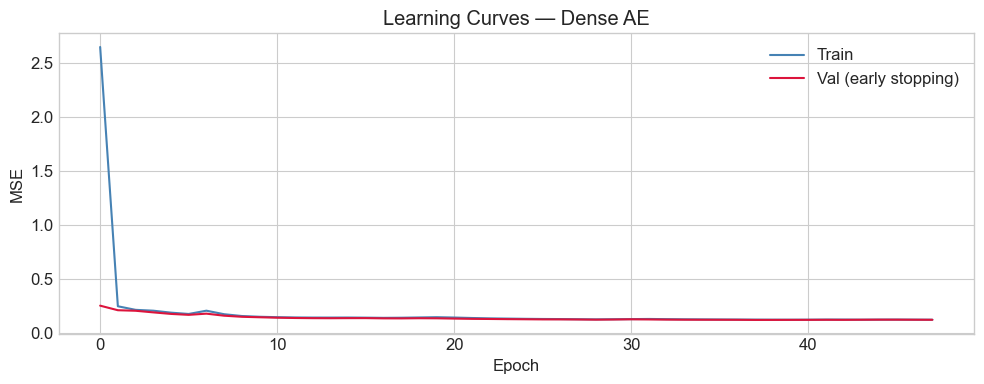

Best val_loss: 0.117451


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], 'steelblue', label='Train')
ax.plot(history.history['val_loss'], 'crimson', label='Val (early stopping)')
ax.set(xlabel='Epoch', ylabel='MSE', title='Learning Curves — Dense AE')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Best val_loss: {min(history.history["val_loss"]):.6f}')

## 5. Calibration: Weighted MSE + Threshold

### Why a uniform MSE is suboptimal

The standard reconstruction error, MSE = mean(Σ (x_i − x̂_i)²), treats all features equally. In practice only three or four features carry the attack signal (GAP, VI_residual, vi_res_abs, Voltage); the rest are reconstructed accurately even under attack and merely dilute the score.

### The fix: a weighted MSE

1. Compute the reconstruction error **per feature** on the validation set.
2. Measure each feature's **discriminative power** as its individual AUC-ROC.
3. Turn those AUCs into weights, so more discriminative features count more.
4. Calibrate the detection threshold on the resulting weighted score.

In [7]:
def calibrate_threshold(y_true, scores, beta=1.0):
    """Find the threshold that maximises F_beta, sweeping the precision-recall curve."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    precisions = precisions[:-1]
    recalls    = recalls[:-1]
    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))
    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]
    n = len(thresholds)
    idx = np.linspace(0, n-1, min(500, n), dtype=int)
    results_df = pd.DataFrame({
        'threshold':  thresholds[idx],
        'precision':  precisions[idx],
        'recall':     recalls[idx],
        'f1': ((2 * precisions * recalls) / (precisions + recalls + 1e-10))[idx],
        'f2': ((5 * precisions * recalls) / (4 * precisions + recalls + 1e-10))[idx],
    })
    return best_thr, fbeta[best_idx], results_df


# ── Step 1: per-feature reconstruction error on val ──
X_val_pred = ae.predict(X_val, batch_size=4096, verbose=0)
mse_per_feature_val = (X_val - X_val_pred) ** 2  # shape: (n_val, n_features)

# ── Step 2: individual AUC-ROC per feature, used to derive the weights ──
print('Discriminative power per feature (individual AUC-ROC):')
feature_aucs = []
for j, fname in enumerate(feat_names):
    try:
        auc_j = roc_auc_score(y_val, mse_per_feature_val[:, j])
    except ValueError:
        auc_j = 0.5
    feature_aucs.append(auc_j)
    marker = ' <<<' if auc_j > 0.60 else ''
    print(f'  {fname:30s}  AUC={auc_j:.4f}{marker}')

feature_aucs = np.array(feature_aucs)

# ── Step 3: weights = AUC above 0.5, normalised (non-discriminative features → 0) ──
weights = np.maximum(feature_aucs - 0.5, 0)  # keep only features that discriminate
weights = weights / (weights.sum() + 1e-10)    # normalise to sum to 1
print()
print('Normalised weights:')
for j, fname in enumerate(feat_names):
    if weights[j] > 0.01:
        print(f'  {fname:30s}  w={weights[j]:.4f}')

# ── Step 4: combine into the weighted score ──
scores_val = np.sum(mse_per_feature_val * weights[None, :], axis=1)

X_test_pred = ae.predict(X_test, batch_size=4096, verbose=0)
mse_per_feature_test = (X_test - X_test_pred) ** 2
scores_test = np.sum(mse_per_feature_test * weights[None, :], axis=1)

# ── Step 5: calibrate the threshold on val ──
# v4: calibrate with F2 (recall weighted above precision). In a security setting
# a false alarm is cheaper than a missed attack, so we tolerate FPs to avoid FNs.
best_thr, best_f2, cal_df = calibrate_threshold(y_val, scores_val, beta=2.0)
_, best_f1_val, _ = calibrate_threshold(y_val, scores_val, beta=1.0)

print()
print(f'Score: weighted MSE (weighted by per-feature AUC)')
print(f'Optimal threshold (val, F2): {best_thr:.6f}')
print(f'  F2 on val: {best_f2:.4f}  (optimised)')
print(f'  F1 on val: {best_f1_val:.4f}')

Discriminative power per feature (individual AUC-ROC):
  Global_active_power             AUC=0.8019 <<<
  Global_reactive_power           AUC=0.7925 <<<
  Voltage                         AUC=0.7761 <<<
  Global_intensity                AUC=0.8125 <<<
  Sub_metering_1                  AUC=0.7851 <<<
  Sub_metering_2                  AUC=0.7803 <<<
  Sub_metering_3                  AUC=0.6935 <<<
  VI_residual                     AUC=0.8777 <<<
  hour_sin                        AUC=0.6155 <<<
  hour_cos                        AUC=0.5633
  dow_sin                         AUC=0.5390
  dow_cos                         AUC=0.5058
  gap_diff1                       AUC=0.8484 <<<
  vi_res_abs                      AUC=0.8800 <<<
  vi_res_roll15_mean              AUC=0.8764 <<<
  gap_intensity_ratio             AUC=0.9088 <<<
  sm_gap_ratio                    AUC=0.7687 <<<

Normalised weights:
  Global_active_power             w=0.0698
  Global_reactive_power           w=0.0676
  Voltage        

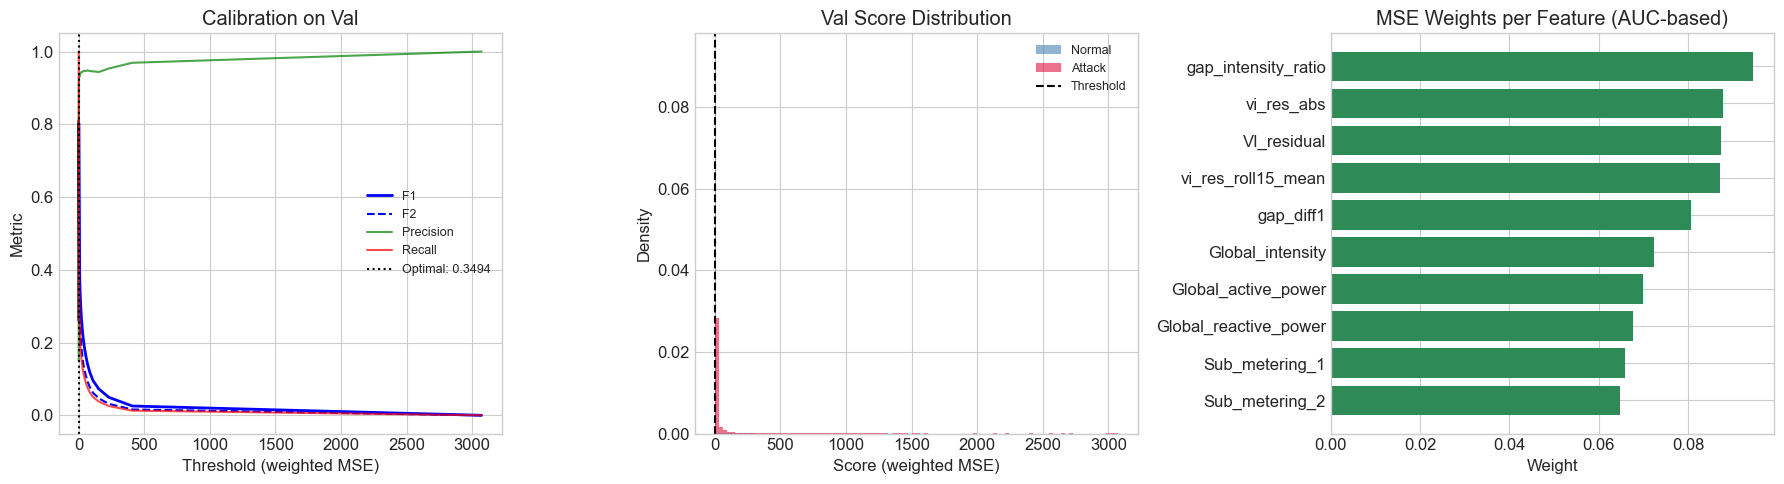

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: P/R/F1/F2 vs threshold
ax = axes[0]
ax.plot(cal_df['threshold'], cal_df['f1'], 'b-', lw=2, label='F1')
ax.plot(cal_df['threshold'], cal_df['f2'], 'b--', lw=1.5, label='F2')
ax.plot(cal_df['threshold'], cal_df['precision'], 'g-', lw=1.5, label='Precision', alpha=0.7)
ax.plot(cal_df['threshold'], cal_df['recall'], 'r-', lw=1.5, label='Recall', alpha=0.7)
ax.axvline(best_thr, color='k', linestyle=':', lw=1.5, label=f'Optimal: {best_thr:.4f}')
ax.set(xlabel='Threshold (weighted MSE)', ylabel='Metric', title='Calibration on Val')
ax.legend(fontsize=9)

# Middle: score distribution
ax = axes[1]
ax.hist(scores_val[y_val == 0], bins=100, alpha=0.6, color='steelblue',
        label='Normal', density=True)
ax.hist(scores_val[y_val == 1], bins=100, alpha=0.6, color='crimson',
        label='Attack', density=True)
ax.axvline(best_thr, color='k', linestyle='--', lw=1.5, label='Threshold')
ax.set(xlabel='Score (weighted MSE)', ylabel='Density',
       title='Val Score Distribution')
ax.legend(fontsize=9)

# Right: weights per feature
ax = axes[2]
sorted_idx = np.argsort(weights)[::-1]
top_n = min(10, (weights > 0.01).sum())
top_idx = sorted_idx[:top_n]
ax.barh([feat_names[j] for j in top_idx], weights[top_idx], color='seagreen')
ax.set_xlabel('Weight')
ax.set_title('MSE Weights per Feature (AUC-based)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Raw Evaluation (before post-processing)

In [9]:
y_pred = (scores_test > best_thr).astype(int)

print('=' * 60)
print('METRICS — DENSE AUTOENCODER')
print('=' * 60)
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

f1  = f1_score(y_test, y_pred)
f2  = fbeta_score(y_test, y_pred, beta=2)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, scores_test)
auc_pr  = average_precision_score(y_test, scores_test)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1:.4f}  |  F2: {f2:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')

METRICS — DENSE AUTOENCODER

              precision    recall  f1-score   support

      Normal       0.97      0.93      0.95    508282
      Attack       0.71      0.85      0.77     96717

    accuracy                           0.92    604999
   macro avg       0.84      0.89      0.86    604999
weighted avg       0.93      0.92      0.92    604999

AUC-ROC: 0.9304  |  AUC-PR: 0.8176
F1: 0.7705  |  F2: 0.8146  |  Precision: 0.7068  |  Recall: 0.8469


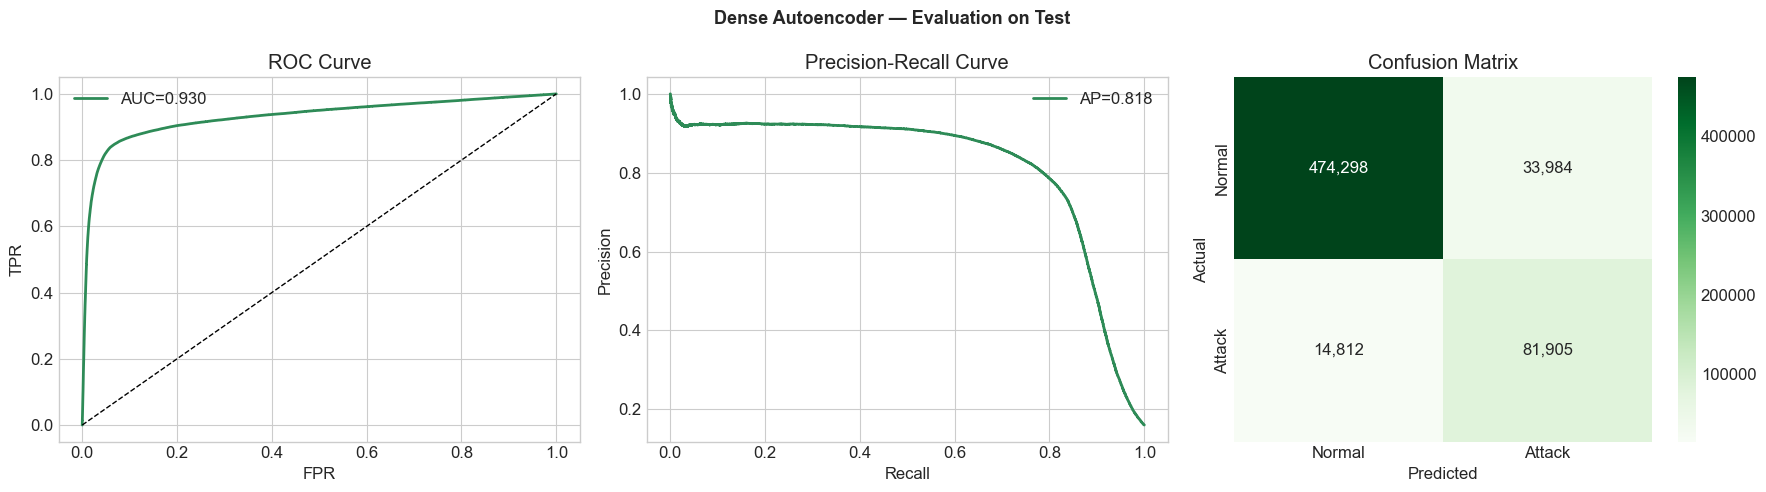

In [10]:
# ROC + PR + Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr, tpr, 'seagreen', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()

pr_c, rc_c, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c, pr_c, 'seagreen', lw=2, label=f'AP={auc_pr:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Greens',
            ax=axes[2], xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
axes[2].set(xlabel='Predicted', ylabel='Actual', title='Confusion Matrix')

plt.suptitle('Dense Autoencoder — Evaluation on Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Temporal Post-processing — Voting Filter

In [11]:
def temporal_vote_vectorized(y_pred, W, K):
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)

y_pred_val_raw = (scores_val > best_thr).astype(int)
print(f'Raw positives on val: {y_pred_val_raw.sum():,} ({y_pred_val_raw.mean()*100:.1f}%)')

W_candidates = [3, 5, 7, 9, 11, 15, 21, 30]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(y_pred_val_raw, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        grid_results.append({'W': W, 'K': K, 'f1': f1_sm,
                             'precision': pr_sm, 'recall': rc_sm})
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'Best (W,K): W={best_W}, K={best_K}')
print(f'  F1={best_row["f1"]:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')

Raw positives on val: 24,824 (17.2%)
Best (W,K): W=3, K=3
  F1=0.8220  P=0.8586  R=0.7883


In [12]:
y_pred_raw    = (scores_test > best_thr).astype(int)
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)

print('=' * 70)
print('COMPARISON — DENSE AE: RAW vs TEMPORAL VOTING')
print('=' * 70)
print()
print(f'  {"Metric":12s} {"Raw":>10s} {"Smoothed":>10s} {"Delta":>10s}')
print('  ' + '-' * 45)
for name, raw_v, sm_v in [
    ('F1',        f1,   f1_s),
    ('F2',        f2,   f2_s),
    ('Precision',  prec,  prec_s),
    ('Recall',     rec,   rec_s),
]:
    delta = sm_v - raw_v
    print(f'  {name:12s} {raw_v:>10.4f} {sm_v:>10.4f} {delta:>+10.4f}')
print()
print(f'  Filter: W={best_W}, K={best_K}')
print()
print(classification_report(y_test, y_pred_smooth, target_names=['Normal', 'Attack']))

COMPARISON — DENSE AE: RAW vs TEMPORAL VOTING

  Metric              Raw   Smoothed      Delta
  ---------------------------------------------
  F1               0.7705     0.8083    +0.0378
  F2               0.8146     0.8073    -0.0072
  Precision        0.7068     0.8099    +0.1032
  Recall           0.8469     0.8067    -0.0401

  Filter: W=3, K=3

              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96    508282
      Attack       0.81      0.81      0.81     96717

    accuracy                           0.94    604999
   macro avg       0.89      0.89      0.89    604999
weighted avg       0.94      0.94      0.94    604999



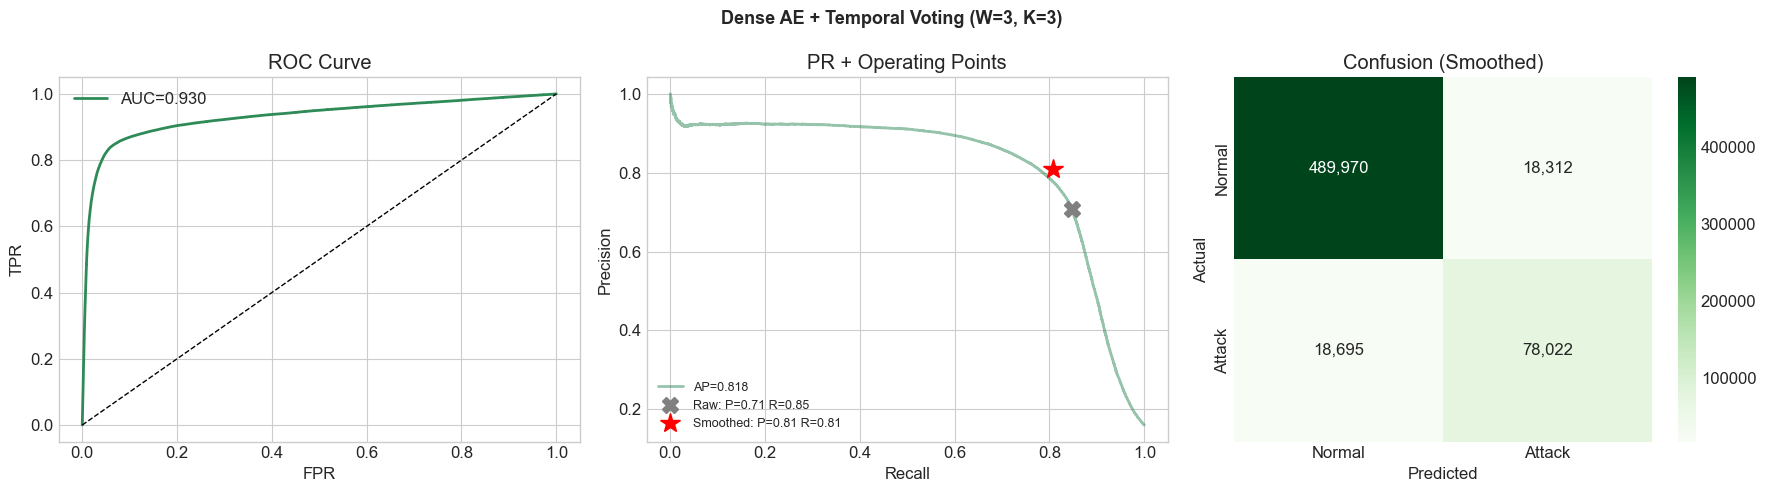

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_s, tpr_s, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr_s, tpr_s, 'seagreen', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()

pr_c2, rc_c2, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c2, pr_c2, 'seagreen', lw=2, label=f'AP={auc_pr:.3f}', alpha=0.5)
axes[1].plot(rec, prec, 'X', color='gray', markersize=12,
             label=f'Raw: P={prec:.2f} R={rec:.2f}')
axes[1].plot(rec_s, prec_s, '*', color='red', markersize=15,
             label=f'Smoothed: P={prec_s:.2f} R={rec_s:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR + Operating Points')
axes[1].legend(fontsize=9)

cm_s = confusion_matrix(y_test, y_pred_smooth)
sns.heatmap(cm_s, annot=True, fmt=',d', cmap='Greens', ax=axes[2],
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
axes[2].set(xlabel='Predicted', ylabel='Actual', title='Confusion (Smoothed)')
plt.suptitle(f'Dense AE + Temporal Voting (W={best_W}, K={best_K})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Recall by Attack Type and Severity (Smoothed)

In [14]:
def temporal_vote_vectorized(y_pred, W, K):
    '''Causal K-of-W voting filter, computed in O(n) via a cumulative sum.'''
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)

y_pred_val_raw = (scores_val > best_thr).astype(int)
print(f'Raw predictions on val: {y_pred_val_raw.sum():,} ({y_pred_val_raw.mean()*100:.1f}%)')

W_candidates = [3, 5, 7, 9, 11, 15, 21, 30]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(y_pred_val_raw, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        grid_results.append({'W': W, 'K': K, 'f1': f1_sm,
                             'precision': pr_sm, 'recall': rc_sm})
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'Best (W,K): W={best_W}, K={best_K}')
print(f'  F1={best_row["f1"]:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')

Raw predictions on val: 24,824 (17.2%)
Best (W,K): W=3, K=3
  F1=0.8220  P=0.8586  R=0.7883


## 9. Detection Latency (Smoothed)

In [15]:
def compute_detection_latency(df_preds, score_col, threshold):
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id, 'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0], 'duration_min': len(group),
            'latency_min': ((detections.index[0] - ep_start).total_seconds() / 60
                            if len(detections) > 0 else np.nan),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)

def print_latency_summary(lat_df):
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    med_lat  = detected['latency_min'].median() if len(detected) > 0 else np.nan
    print(f'Detection per episode: {det_rate:.1%} ({lat_df["detected"].sum()}/{len(lat_df)})')
    if not np.isnan(med_lat):
        print(f'Median latency:        {med_lat:.1f} min')
    print()
    for sev in ['low', 'medium', 'high']:
        sub = lat_df[lat_df['severity'] == sev]
        if len(sub) == 0: continue
        det = sub['detected'].mean()
        det_sub = sub[sub['detected']]
        lat = det_sub['latency_min'].median() if len(det_sub) > 0 else np.nan
        lat_s = f'{lat:.1f} min' if not np.isnan(lat) else 'N/A'
        print(f'  {sev:8s}: detection {det:.0%}  |  median latency {lat_s}')
    return det_rate, med_lat

df_test_scored = df_test.copy()
df_test_scored['dae_pred_smooth'] = y_pred_smooth.astype(float)
lat_df = compute_detection_latency(df_test_scored, 'dae_pred_smooth', 0.5)
det_rate, med_lat = print_latency_summary(lat_df)

Detection per episode: 98.8% (830/840)
Median latency:        2.0 min

  low     : detection 96%  |  median latency 4.0 min
  medium  : detection 100%  |  median latency 2.0 min
  high    : detection 100%  |  median latency 2.0 min


## 10. Edge Footprint + Saving Artefacts

In [16]:
model_path = os.path.join(DATA_DIR, 'model_dense_autoencoder.keras')
try:
    ae.save(model_path)
except Exception:
    model_path = os.path.join(DATA_DIR, 'model_dense_autoencoder.h5')
    ae.save(model_path)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_dense_autoencoder.pkl'))

# Persist the per-feature weights needed to reproduce the weighted MSE at inference
np.save(os.path.join(DATA_DIR, 'feature_weights_dense_ae.npy'), weights)

_ = ae.predict(X_test[:100], batch_size=4096, verbose=0)
times = []
for _ in range(5):
    t0 = time.time()
    ae.predict(X_test, batch_size=4096, verbose=0)
    times.append(time.time() - t0)
ms_avg = np.mean(times) / len(X_test) * 1000

print('=' * 55)
print('EDGE COMPUTING — DENSE AE v3')
print('=' * 55)
print(f'  Parameters:    {ae.count_params():,}')
print(f'  Bottleneck:    3 (ratio {n_features}:3 = {n_features/3:.1f}:1)')
print(f'  Scoring:       weighted MSE ({(weights>0.01).sum()} active features)')
print(f'  Filter:        W={best_W}, K={best_K}')
print(f'  Size:          {size_kb:.1f} KB')
print(f'  Latency:       {ms_avg:.4f} ms/sample')
print(f'  Throughput:    {1000/ms_avg:,.0f} samples/s')
print(f'  Training:      {t_train:.1f} s')

df_out = df_test.copy()
df_out['dae_score'] = scores_test
df_out['dae_pred_raw']    = y_pred_raw
df_out['dae_pred_smooth'] = y_pred_smooth
df_out.to_csv(os.path.join(DATA_DIR, 'predictions_dense_autoencoder.csv'))
np.save(os.path.join(DATA_DIR, 'threshold_dense_ae.npy'), np.array([best_thr]))
lat_df.to_csv(os.path.join(DATA_DIR, 'latency_dense_autoencoder.csv'), index=False)

metrics = {
    'model': 'Dense Autoencoder v3 + Temporal Voting',
    'feature_mode': 'medium + vi_res_abs',
    'scoring': 'weighted_mse',
    'raw_f1': round(f1, 4), 'raw_f2': round(f2, 4),
    'raw_precision': round(prec, 4), 'raw_recall': round(rec, 4),
    'f1': round(f1_s, 4), 'f2': round(f2_s, 4),
    'precision': round(prec_s, 4), 'recall': round(rec_s, 4),
    'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),
    'threshold': round(float(best_thr), 8),
    'temporal_W': best_W, 'temporal_K': best_K,
    'model_size_kb': round(size_kb, 1), 'ms_per_sample': round(ms_avg, 4),
    'n_params': ae.count_params(), 'n_features': n_features, 'bottleneck': 3,
    'train_time_s': round(t_train, 1),
    'detection_rate': round(det_rate, 4),
    'median_latency_min': round(float(med_lat), 1) if not np.isnan(med_lat) else None,
    'granularity': '1 min',
    'feature_names': feat_names,
    'feature_weights': {fn: round(float(w), 4) for fn, w in zip(feat_names, weights) if w > 0.01},
}
with open(os.path.join(DATA_DIR, 'metrics_dense_autoencoder.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print()
print('Saved in data/:')
for fn in ['predictions_dense_autoencoder.csv', 'metrics_dense_autoencoder.json',
           'model_dense_autoencoder.keras', 'scaler_dense_autoencoder.pkl',
           'threshold_dense_ae.npy', 'feature_weights_dense_ae.npy',
           'latency_dense_autoencoder.csv']:
    print(f'  * {fn}')

EDGE COMPUTING — DENSE AE v3
  Parameters:    6,741
  Bottleneck:    3 (ratio 17:3 = 5.7:1)
  Scoring:       weighted MSE (15 active features)
  Filter:        W=3, K=3
  Size:          134.0 KB
  Latency:       0.0004 ms/sample
  Throughput:    2,324,261 samples/s
  Training:      561.0 s

Saved in data/:
  * predictions_dense_autoencoder.csv
  * metrics_dense_autoencoder.json
  * model_dense_autoencoder.keras
  * scaler_dense_autoencoder.pkl
  * threshold_dense_ae.npy
  * feature_weights_dense_ae.npy
  * latency_dense_autoencoder.csv
